<a href="https://colab.research.google.com/github/Rakshitha443/ITA-0610-MACHINE-LEARNING-/blob/main/RAKSHITHA_T_192212443_ACTIVITY_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random

# Configuration
CHROMOSOME_LENGTH = 5  # 2^5 = 32 values (0 to 31)
POPULATION_SIZE = 6


def decode_chromosome(binary_str):
  return int(binary_str, 2)


def fitness_function(x):
  return x**2


# 1. Random Population Generation
random.seed(42)  # For reproducible results
population = [
    "".join(random.choice("01") for _ in range(CHROMOSOME_LENGTH))
    for _ in range(POPULATION_SIZE)
]

# 2. Decode and Compute Fitness
decoded_x = [decode_chromosome(chrom) for chrom in population]
fitness_values = [fitness_function(x) for x in decoded_x]

# 3. Find Best Chromosome
best_idx = fitness_values.index(max(fitness_values))

# Display Results
print("=" * 60)
print("Q1: BASIC GENETIC ALGORITHM EVALUATION")
print("=" * 60)
print(f"Initial Population: {population}")
print(f"Decoded Values (x): {decoded_x}")
print(f"Fitness Values f(x): {fitness_values}")
print("-" * 60)
print(f"Best Chromosome : {population[best_idx]}")
print(f"Best Value (x)  : {decoded_x[best_idx]}")
print(f"Best Fitness    : {fitness_values[best_idx]}")
print("=" * 60)

Q1: BASIC GENETIC ALGORITHM EVALUATION
Initial Population: ['00100', '00010', '00000', '01011', '00111', '00100']
Decoded Values (x): [4, 2, 0, 11, 7, 4]
Fitness Values f(x): [16, 4, 0, 121, 49, 16]
------------------------------------------------------------
Best Chromosome : 01011
Best Value (x)  : 11
Best Fitness    : 121


2)

Gen 01 | Best Chromosome: [1 1 1 1 1 1] | x: 63 | Fitness: 131
Gen 02 | Best Chromosome: [1 1 1 1 1 1] | x: 63 | Fitness: 131
Gen 03 | Best Chromosome: [1 1 1 1 1 1] | x: 63 | Fitness: 131
Gen 04 | Best Chromosome: [1 1 1 1 1 1] | x: 63 | Fitness: 131
Gen 05 | Best Chromosome: [1 1 1 1 1 1] | x: 63 | Fitness: 131
Gen 06 | Best Chromosome: [1 1 1 1 1 1] | x: 63 | Fitness: 131
Gen 07 | Best Chromosome: [1 1 1 0 1 0] | x: 58 | Fitness: 121
Gen 08 | Best Chromosome: [1 1 1 0 1 0] | x: 58 | Fitness: 121
Gen 09 | Best Chromosome: [1 1 1 0 1 0] | x: 58 | Fitness: 121
Gen 10 | Best Chromosome: [1 1 1 0 1 1] | x: 59 | Fitness: 123


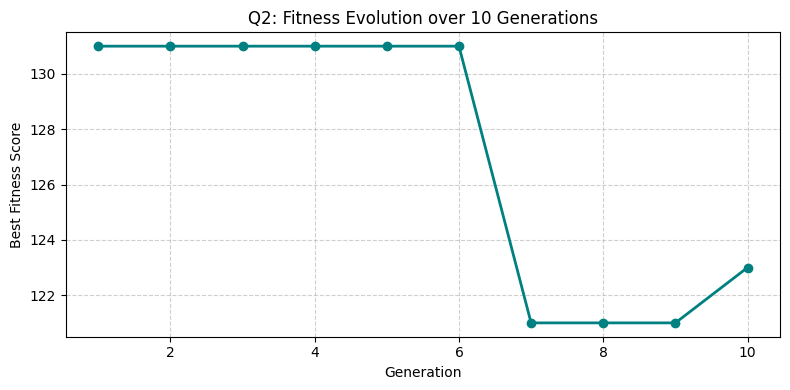

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration
POP_SIZE = 8
CHROM_LEN = 6  # 2^6 = 64 values (0 to 63)
MUTATION_RATE = 0.1
GENERATIONS = 10

np.random.seed(42)


def decode(binary_arr):
  return int("".join(map(str, binary_arr)), 2)


def fitness(x):
  return 2 * x + 5


# Initialize Population (8 individuals, 6 bits each)
population = np.random.randint(0, 2, size=(POP_SIZE, CHROM_LEN))

best_fitness_history = []

for gen in range(GENERATIONS):
  decoded = [decode(ind) for ind in population]
  fits = np.array([fitness(x) for x in decoded])

  # Track Best Individual
  best_idx = np.argmax(fits)
  best_fitness_history.append(fits[best_idx])
  print(
      f"Gen {gen+1:02d} | Best Chromosome: {population[best_idx]} | x:"
      f" {decoded[best_idx]:2d} | Fitness: {fits[best_idx]}"
  )

  # Selection (Roulette Wheel)
  probs = fits / fits.sum()
  selected_indices = np.random.choice(POP_SIZE, size=POP_SIZE, p=probs)
  population = population[selected_indices].copy()

  # Single-Point Crossover
  next_pop = []
  for i in range(0, POP_SIZE, 2):
    parent1, parent2 = population[i], population[i + 1]
    pt = np.random.randint(1, CHROM_LEN)
    child1 = np.concatenate([parent1[:pt], parent2[pt:]])
    child2 = np.concatenate([parent2[:pt], parent1[pt:]])
    next_pop.extend([child1, child2])
  population = np.array(next_pop)

  # Bit-Flip Mutation
  mutation_mask = np.random.rand(*population.shape) < MUTATION_RATE
  population = np.bitwise_xor(population, mutation_mask.astype(int))

# Plot Fitness Evolution
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, GENERATIONS + 1),
    best_fitness_history,
    marker="o",
    color="teal",
    linewidth=2,
)
plt.title("Q2: Fitness Evolution over 10 Generations")
plt.xlabel("Generation")
plt.ylabel("Best Fitness Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

3)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def run_ga_experiment(mutation_rate, generations=20, pop_size=10, chrom_len=6):
  np.random.seed(123)
  population = np.random.randint(0, 2, size=(pop_size, chrom_len))

  best_fitness_log = []
  diversity_log = []

  for _ in range(generations):
    decoded = [
        int("".join(map(str, ind)), 2) for ind in population
    ]
    fits = np.array([x**2 + 10 for x in decoded])

    # Record Metrics
    best_fitness_log.append(np.max(fits))
    # Diversity measured as standard deviation of unique chromosomes in population
    diversity_log.append(len(np.unique(population, axis=0)))

    # Selection
    probs = fits / fits.sum()
    population = population[
        np.random.choice(pop_size, size=pop_size, p=probs)
    ].copy()

    # Crossover
    next_pop = []
    for i in range(0, pop_size, 2):
      pt = np.random.randint(1, chrom_len)
      c1 = np.concatenate([population[i][:pt], population[i + 1][pt:]])
      c2 = np.concatenate([population[i + 1][:pt], population[i][pt:]])
      next_pop.extend([c1, c2])
    population = np.array(next_pop)

    # Mutation
    mask = np.random.rand(*population.shape) < mutation_rate
    population = np.bitwise_xor(population, mask.astype(int))

  return best_fitness_log, diversity_log


# Run Experiments
fit_A, div_A = run_ga_experiment(mutation_rate=0.01)
fit_B, div_B = run_ga_experiment(mutation_rate=0.20)

# Display Summary Table
df_compare = pd.DataFrame({
    'Metric': [
        'Convergence Speed (Gen to reach >90% Max)',
        'Final Best Fitness',
        'Average Population Diversity (Unique Chromosomes)',
    ],
    'Mutation Rate A (0.01)': [
        np.argmax(np.array(fit_A) >= 0.9 * max(fit_A)) + 1,
        max(fit_A),
        f'{np.mean(div_A):.2f} / 10',
    ],
    'Mutation Rate B (0.20)': [
        np.argmax(np.array(fit_B) >= 0.9 * max(fit_B)) + 1,
        max(fit_B),
        f'{np.mean(div_B):.2f} / 10',
    ],
})

print("=" * 80)
print("Q3: MUTATION RATE COMPARISON ANALYSIS")
print("=" * 80)
print(df_compare.to_string(index=False))
print("=" * 80)

# Graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    range(1, 21), fit_A, label="Mutation Rate 0.01 (Low)", color="blue"
)
axes[0].plot(
    range(1, 21), fit_B, label="Mutation Rate 0.20 (High)", color="crimson"
)
axes[0].set_title("Fitness Convergence Comparison")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best Fitness")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    range(1, 21), div_A, label="Mutation Rate 0.01 (Low)", color="blue"
)
axes[1].plot(
    range(1, 21), div_B, label="Mutation Rate 0.20 (High)", color="crimson"
)
axes[1].set_title("Population Diversity Trajectory")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Number of Unique Chromosomes")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

Q3: MUTATION RATE COMPARISON ANALYSIS
                                           Metric Mutation Rate A (0.01) Mutation Rate B (0.20)
        Convergence Speed (Gen to reach >90% Max)                     17                      5
                               Final Best Fitness                   3731                   3979
Average Population Diversity (Unique Chromosomes)              3.40 / 10              8.45 / 10


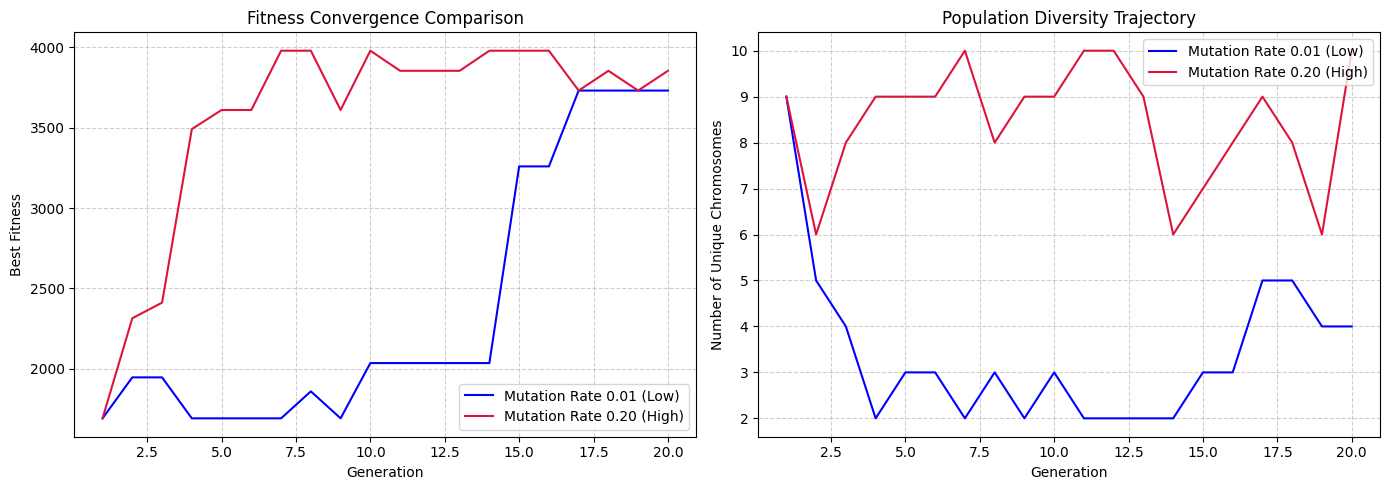

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def run_ga_experiment(mutation_rate, generations=20, pop_size=10, chrom_len=6):
  np.random.seed(123)
  population = np.random.randint(0, 2, size=(pop_size, chrom_len))

  best_fitness_log = []
  diversity_log = []

  for _ in range(generations):
    decoded = [
        int("".join(map(str, ind)), 2) for ind in population
    ]
    fits = np.array([x**2 + 10 for x in decoded])

    # Record Metrics
    best_fitness_log.append(np.max(fits))
    diversity_log.append(len(np.unique(population, axis=0)))

    # Selection (Roulette Wheel)
    probs = fits / fits.sum()
    population = population[
        np.random.choice(pop_size, size=pop_size, p=probs)
    ].copy()

    # Single-Point Crossover
    next_pop = []
    for i in range(0, pop_size, 2):
      pt = np.random.randint(1, chrom_len)
      # Child 1: Parent 1 prefix + Parent 2 suffix
      c1 = np.concatenate([population[i][:pt], population[i + 1][pt:]])
      # Child 2: Parent 2 prefix + Parent 1 suffix (FIXED HERE)
      c2 = np.concatenate([population[i + 1][:pt], population[i][pt:]])
      next_pop.extend([c1, c2])
    population = np.array(next_pop)

    # Bit-Flip Mutation
    mask = np.random.rand(*population.shape) < mutation_rate
    population = np.bitwise_xor(population, mask.astype(int))

  return best_fitness_log, diversity_log


# Run Experiments
fit_A, div_A = run_ga_experiment(mutation_rate=0.01)
fit_B, div_B = run_ga_experiment(mutation_rate=0.20)

# Display Summary Table
df_compare = pd.DataFrame({
    'Metric': [
        'Convergence Speed (Gen to reach >90% Max)',
        'Final Best Fitness',
        'Average Population Diversity (Unique Chromosomes)',
    ],
    'Mutation Rate A (0.01)': [
        np.argmax(np.array(fit_A) >= 0.9 * max(fit_A)) + 1,
        max(fit_A),
        f'{np.mean(div_A):.2f} / 10',
    ],
    'Mutation Rate B (0.20)': [
        np.argmax(np.array(fit_B) >= 0.9 * max(fit_B)) + 1,
        max(fit_B),
        f'{np.mean(div_B):.2f} / 10',
    ],
})

print("=" * 80)
print("Q3: MUTATION RATE COMPARISON ANALYSIS")
print("=" * 80)
print(df_compare.to_string(index=False))
print("=" * 80)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    range(1, 21), fit_A, label="Mutation Rate 0.01 (Low)", color="blue"
)
axes[0].plot(
    range(1, 21), fit_B, label="Mutation Rate 0.20 (High)", color="crimson"
)
axes[0].set_title("Fitness Convergence Comparison")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best Fitness")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(
    range(1, 21), div_A, label="Mutation Rate 0.01 (Low)", color="blue"
)
axes[1].plot(
    range(1, 21), div_B, label="Mutation Rate 0.20 (High)", color="crimson"
)
axes[1].set_title("Population Diversity Trajectory")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Number of Unique Chromosomes")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

4)

In [5]:
import numpy as np

# Configuration
LR_MIN, LR_MAX = 0.001, 0.1
CHROM_LEN = 10  # 10-bit resolution
POP_SIZE = 10
GENERATIONS = 15


def decode_lr(binary_arr):
  integer_val = int("".join(map(str, binary_arr)), 2)
  # Scale integer from [0, 2^10 - 1] to range [LR_MIN, LR_MAX]
  return LR_MIN + (integer_val / (2**CHROM_LEN - 1)) * (LR_MAX - LR_MIN)


def accuracy_fitness(lr):
  return 100.0 - ((lr - 0.05) ** 2) * 1000.0


def run_selection_experiment(selection_type='roulette'):
  np.random.seed(42)
  population = np.random.randint(0, 2, size=(POP_SIZE, CHROM_LEN))

  for _ in range(GENERATIONS):
    lrs = [decode_lr(ind) for ind in population]
    fits = np.array([accuracy_fitness(lr) for lr in lrs])

    # SELECTION STRATEGY
    if selection_type == 'roulette':
      # Normalize fits for roulette selection
      fits_norm = fits - np.min(fits) + 1e-5
      probs = fits_norm / fits_norm.sum()
      selected_idx = np.random.choice(POP_SIZE, size=POP_SIZE, p=probs)
    elif selection_type == 'tournament':
      # Tournament Selection (K=3)
      selected_idx = []
      for _ in range(POP_SIZE):
        competitors = np.random.choice(POP_SIZE, size=3, replace=False)
        winner = competitors[np.argmax(fits[competitors])]
        selected_idx.append(winner)

    population = population[selected_idx].copy()

    # Crossover & Mutation
    next_pop = []
    for i in range(0, POP_SIZE, 2):
      pt = np.random.randint(1, CHROM_LEN)
      c1 = np.concatenate([population[i][:pt], population[i + 1][pt:]])
      c2 = np.concatenate([population[i + 1][:pt], population[i][:pt]])
      next_pop.extend([c1, c2])
    population = np.array(next_pop)

    mask = np.random.rand(*population.shape) < 0.05
    population = np.bitwise_xor(population, mask.astype(int))

  final_lrs = [decode_lr(ind) for ind in population]
  final_fits = [accuracy_fitness(lr) for lr in final_lrs]
  best_idx = np.argmax(final_fits)
  return final_lrs[best_idx], final_fits[best_idx]


best_lr_rw, best_fit_rw = run_selection_experiment('roulette')
best_lr_tn, best_fit_tn = run_selection_experiment('tournament')

print("=" * 75)
print("Q4: SELECTION METHOD EVALUATION (LR HYPERPARAMETER OPTIMIZATION)")
print("=" * 75)
print(
    f"Roulette Wheel Selection -> Best LR: {best_lr_rw:.6f} | Accuracy:"
    f" {best_fit_rw:.4f}%"
)
print(
    f"Tournament Selection     -> Best LR: {best_lr_tn:.6f} | Accuracy:"
    f" {best_fit_tn:.4f}%"
)
print("=" * 75)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [6]:
import numpy as np

# Configuration
LR_MIN, LR_MAX = 0.001, 0.1
CHROM_LEN = 10  # 10-bit resolution
POP_SIZE = 10
GENERATIONS = 15


def decode_lr(binary_arr):
  integer_val = int("".join(map(str, binary_arr)), 2)
  # Scale integer from [0, 2^10 - 1] to range [LR_MIN, LR_MAX]
  return LR_MIN + (integer_val / (2**CHROM_LEN - 1)) * (LR_MAX - LR_MIN)


def accuracy_fitness(lr):
  return 100.0 - ((lr - 0.05) ** 2) * 1000.0


def run_selection_experiment(selection_type='roulette'):
  np.random.seed(42)
  population = np.random.randint(0, 2, size=(POP_SIZE, CHROM_LEN))

  for _ in range(GENERATIONS):
    lrs = [decode_lr(ind) for ind in population]
    fits = np.array([accuracy_fitness(lr) for lr in lrs])

    # SELECTION STRATEGY
    if selection_type == 'roulette':
      # Normalize fits for roulette selection
      fits_norm = fits - np.min(fits) + 1e-5
      probs = fits_norm / fits_norm.sum()
      selected_idx = np.random.choice(POP_SIZE, size=POP_SIZE, p=probs)
    elif selection_type == 'tournament':
      # Tournament Selection (K=3)
      selected_idx = []
      for _ in range(POP_SIZE):
        competitors = np.random.choice(POP_SIZE, size=3, replace=False)
        winner = competitors[np.argmax(fits[competitors])]
        selected_idx.append(winner)

    population = population[selected_idx].copy()

    # Crossover & Mutation
    next_pop = []
    for i in range(0, POP_SIZE, 2):
      pt = np.random.randint(1, CHROM_LEN)
      # Child 1: Parent 1 prefix + Parent 2 suffix
      c1 = np.concatenate([population[i][:pt], population[i + 1][pt:]])
      # Child 2: Parent 2 prefix + Parent 1 suffix (FIXED HERE)
      c2 = np.concatenate([population[i + 1][:pt], population[i][pt:]])
      next_pop.extend([c1, c2])
    population = np.array(next_pop)

    mask = np.random.rand(*population.shape) < 0.05
    population = np.bitwise_xor(population, mask.astype(int))

  final_lrs = [decode_lr(ind) for ind in population]
  final_fits = [accuracy_fitness(lr) for lr in final_lrs]
  best_idx = np.argmax(final_fits)
  return final_lrs[best_idx], final_fits[best_idx]


best_lr_rw, best_fit_rw = run_selection_experiment('roulette')
best_lr_tn, best_fit_tn = run_selection_experiment('tournament')

print("=" * 75)
print("Q4: SELECTION METHOD EVALUATION (LR HYPERPARAMETER OPTIMIZATION)")
print("=" * 75)
print(
    f"Roulette Wheel Selection -> Best LR: {best_lr_rw:.6f} | Accuracy:"
    f" {best_fit_rw:.4f}%"
)
print(
    f"Tournament Selection     -> Best LR: {best_lr_tn:.6f} | Accuracy:"
    f" {best_fit_tn:.4f}%"
)
print("=" * 75)

Q4: SELECTION METHOD EVALUATION (LR HYPERPARAMETER OPTIMIZATION)
Roulette Wheel Selection -> Best LR: 0.050161 | Accuracy: 100.0000%
Tournament Selection     -> Best LR: 0.049968 | Accuracy: 100.0000%


5)

In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# 1. Load Real World Dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
N_FEATURES = X.shape[1]

# GA Parameters
POP_SIZE = 8
GENERATIONS = 12
MUTATION_RATE = 0.1

np.random.seed(42)


# Fitness Function Evaluation
def evaluate_feature_subset(chromosome):
  selected_mask = np.array(chromosome, dtype=bool)

  # Penalty if no feature is selected
  if not np.any(selected_mask):
    return 0.0, 0.0

  X_subset = X[:, selected_mask]
  clf = DecisionTreeClassifier(random_state=42)

  # 5-Fold Cross Validation Accuracy
  acc = np.mean(cross_val_score(clf, X_subset, y, cv=5))
  num_features = np.sum(selected_mask)

  fitness = acc - (0.01 * num_features)
  return accuracy_score, fitness


# Initialize Random Binary Population
population = np.random.randint(0, 2, size=(POP_SIZE, N_FEATURES))

best_overall_fit = -1
best_overall_chrom = None
best_overall_acc = 0.0

print("=" * 80)
print("Q5: GENETIC ALGORITHM FOR FEATURE SELECTION (IRIS DATASET)")
print("=" * 80)

for gen in range(GENERATIONS):
  fitness_scores = []
  accuracies = []

  for ind in population:
    acc, fit = evaluate_feature_subset(ind)
    accuracies.append(acc)
    fitness_scores.append(fit)

  fitness_scores = np.array(fitness_scores)

  # Track Best
  best_gen_idx = np.argmax(fitness_scores)
  if fitness_scores[best_gen_idx] > best_overall_fit:
    best_overall_fit = fitness_scores[best_gen_idx]
    best_overall_chrom = population[best_gen_idx].copy()
    best_overall_acc = accuracies[best_gen_idx]

  print(
      f"Gen {gen+1:02d} | Best Subset: {population[best_gen_idx]} | CV Acc:"
      f" {accuracies[best_gen_idx]:.4f} | Fitness:"
      f" {fitness_scores[best_gen_idx]:.4f}"
  )

  # Tournament Selection
  selected = []
  for _ in range(POP_SIZE):
    i1, i2 = np.random.choice(POP_SIZE, size=2, replace=False)
    winner = i1 if fitness_scores[i1] > fitness_scores[i2] else i2
    selected.append(population[winner])
  population = np.array(selected)

  # Crossover
  next_pop = []
  for i in range(0, POP_SIZE, 2):
    pt = np.random.randint(1, N_FEATURES)
    c1 = np.concatenate([population[i][:pt], population[i + 1][pt:]])
    c2 = np.concatenate([population[i + 1][:pt], population[i][:pt]])
    next_pop.extend([c1, c2])
  population = np.array(next_pop)

  # Mutation
  mask = np.random.rand(*population.shape) < MUTATION_RATE
  population = np.bitwise_xor(population, mask.astype(int))

# Display Final Selected Subsets
selected_features = [
    feature_names[i]
    for i, bit in enumerate(best_overall_chrom)
    if bit == 1
]

print("-" * 80)
print("OPTIMAL FEATURE SUBSET IDENTIFIED:")
print(f"Chromosome Mask   : {best_overall_chrom}")
print(f"Selected Features : {selected_features}")
print(f"CV Model Accuracy : {best_overall_acc * 100:.2f}%")
print(f"Final Fitness Score: {best_overall_fit:.4f}")
print("=" * 80)

Q5: GENETIC ALGORITHM FOR FEATURE SELECTION (IRIS DATASET)


NameError: name 'accuracy_score' is not defined

In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# 1. Load Real World Dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
N_FEATURES = X.shape[1]

# GA Parameters
POP_SIZE = 8
GENERATIONS = 12
MUTATION_RATE = 0.1

np.random.seed(42)


# Fitness Function Evaluation
def evaluate_feature_subset(chromosome):
  selected_mask = np.array(chromosome, dtype=bool)

  # Penalty if no feature is selected
  if not np.any(selected_mask):
    return 0.0, 0.0

  X_subset = X[:, selected_mask]
  clf = DecisionTreeClassifier(random_state=42)

  # 5-Fold Cross Validation Accuracy
  acc = np.mean(cross_val_score(clf, X_subset, y, cv=5))
  num_features = np.sum(selected_mask)

  fitness = acc - (0.01 * num_features)
  return acc, fitness  # FIXED: returning local variable 'acc' instead of 'accuracy_score'


# Initialize Random Binary Population
population = np.random.randint(0, 2, size=(POP_SIZE, N_FEATURES))

best_overall_fit = -1
best_overall_chrom = None
best_overall_acc = 0.0

print("=" * 80)
print("Q5: GENETIC ALGORITHM FOR FEATURE SELECTION (IRIS DATASET)")
print("=" * 80)

for gen in range(GENERATIONS):
  fitness_scores = []
  accuracies = []

  for ind in population:
    acc, fit = evaluate_feature_subset(ind)
    accuracies.append(acc)
    fitness_scores.append(fit)

  fitness_scores = np.array(fitness_scores)

  # Track Best
  best_gen_idx = np.argmax(fitness_scores)
  if fitness_scores[best_gen_idx] > best_overall_fit:
    best_overall_fit = fitness_scores[best_gen_idx]
    best_overall_chrom = population[best_gen_idx].copy()
    best_overall_acc = accuracies[best_gen_idx]

  print(
      f"Gen {gen+1:02d} | Best Subset: {population[best_gen_idx]} | CV Acc:"
      f" {accuracies[best_gen_idx]:.4f} | Fitness:"
      f" {fitness_scores[best_gen_idx]:.4f}"
  )

  # Tournament Selection
  selected = []
  for _ in range(POP_SIZE):
    i1, i2 = np.random.choice(POP_SIZE, size=2, replace=False)
    winner = i1 if fitness_scores[i1] > fitness_scores[i2] else i2
    selected.append(population[winner])
  population = np.array(selected)

  # Crossover
  next_pop = []
  for i in range(0, POP_SIZE, 2):
    pt = np.random.randint(1, N_FEATURES)
    c1 = np.concatenate([population[i][:pt], population[i + 1][pt:]])
    # FIXED: Slicing parent 1 from pt to the end (population[i][pt:])
    c2 = np.concatenate([population[i + 1][:pt], population[i][pt:]])
    next_pop.extend([c1, c2])
  population = np.array(next_pop)

  # Mutation
  mask = np.random.rand(*population.shape) < MUTATION_RATE
  population = np.bitwise_xor(population, mask.astype(int))

# Display Final Selected Subsets
selected_features = [
    feature_names[i]
    for i, bit in enumerate(best_overall_chrom)
    if bit == 1
]

print("-" * 80)
print("OPTIMAL FEATURE SUBSET IDENTIFIED:")
print(f"Chromosome Mask   : {best_overall_chrom}")
print(f"Selected Features : {selected_features}")
print(f"CV Model Accuracy : {best_overall_acc * 100:.2f}%")
print(f"Final Fitness Score: {best_overall_fit:.4f}")
print("=" * 80)

Q5: GENETIC ALGORITHM FOR FEATURE SELECTION (IRIS DATASET)
Gen 01 | Best Subset: [1 0 1 1] | CV Acc: 0.9533 | Fitness: 0.9233
Gen 02 | Best Subset: [0 1 1 1] | CV Acc: 0.9600 | Fitness: 0.9300
Gen 03 | Best Subset: [0 1 1 1] | CV Acc: 0.9600 | Fitness: 0.9300
Gen 04 | Best Subset: [0 1 1 1] | CV Acc: 0.9600 | Fitness: 0.9300
Gen 05 | Best Subset: [0 0 1 1] | CV Acc: 0.9600 | Fitness: 0.9400
Gen 06 | Best Subset: [0 0 1 1] | CV Acc: 0.9600 | Fitness: 0.9400
Gen 07 | Best Subset: [0 0 0 1] | CV Acc: 0.9533 | Fitness: 0.9433
Gen 08 | Best Subset: [0 0 1 1] | CV Acc: 0.9600 | Fitness: 0.9400
Gen 09 | Best Subset: [0 0 0 1] | CV Acc: 0.9533 | Fitness: 0.9433
Gen 10 | Best Subset: [0 0 0 1] | CV Acc: 0.9533 | Fitness: 0.9433
Gen 11 | Best Subset: [0 0 0 1] | CV Acc: 0.9533 | Fitness: 0.9433
Gen 12 | Best Subset: [0 0 0 1] | CV Acc: 0.9533 | Fitness: 0.9433
--------------------------------------------------------------------------------
OPTIMAL FEATURE SUBSET IDENTIFIED:
Chromosome Mask   : [